# Section 2 – Transfer Learning with VGG16 on 15-Scene Dataset

In [1]:
#!wget https://github.com/cdancette/deep-learning-polytech-tp6-7/raw/master/tp8/15ScenesData.zip
import os

if not os.path.exists("../data/15SceneData"):
    !wget https://github.com/rdfia/rdfia.github.io/raw/master/data/3-a/15ScenesData.zip
    !unzip 15ScenesData.zip -d ../data/
    !rm 15ScenesData.zip
    print("Téléchargement dataset effectué")
else:
    print("Téléchargement dataset déjà effectué")

Téléchargement dataset déjà effectué


In [2]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torch.backends.cudnn as cudnn
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sklearn.svm import LinearSVC
from sklearn.preprocessing import normalize

PRINT_INTERVAL = 50

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    cudnn.benchmark = True
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

In [3]:
class VGG16relu7(nn.Module):
    def __init__(self, vgg16):
        super(VGG16relu7, self).__init__()
        self.features = nn.Sequential(*list(vgg16.features.children()))
        self.classifier = nn.Sequential(*list(vgg16.classifier.children())[:-2]) # Until relu7

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

In [4]:
def duplicateChannel(img):
    img = img.convert('L')
    np_img = np.array(img, dtype=np.uint8)
    np_img = np.dstack([np_img, np_img, np_img])
    img = Image.fromarray(np_img, 'RGB')
    return img

def resizeImage(img):
    return img.resize((224, 224), Image.BILINEAR)

def get_dataset(batch_size, path):
    transform_pipeline = transforms.Compose([
        transforms.Lambda(duplicateChannel),
        transforms.Lambda(resizeImage),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    train_dataset = datasets.ImageFolder(path+'/train', transform=transform_pipeline)
    val_dataset = datasets.ImageFolder(path+'/test', transform=transform_pipeline)

    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader

In [5]:
def extract_features(data, model):
    X = []
    y = []

    for i, (inputs, targets) in enumerate(data):
        if i % PRINT_INTERVAL == 0:
            print('Batch {0:03d}/{1:03d}'.format(i, len(data)))

        inputs = inputs.to(DEVICE)

        with torch.no_grad():
            features = model(inputs)

        X.append(features.cpu().numpy())
        y.append(targets.numpy())

    X = np.concatenate(X, axis=0)
    y = np.concatenate(y, axis=0)
    X = normalize(X, norm='l2')

    return X, y

In [6]:
def show_activationMaps(path="15SceneData", batch_size=8):
    vgg16 = models.vgg16(pretrained=True).eval().to(DEVICE)

    train_loader, test_loader = get_dataset(batch_size, path)
    images, labels = next(iter(train_loader))

    img = images[0].unsqueeze(0).to(DEVICE)

    def get_feature_map(image, model, layer_idx):
        x = image
        with torch.no_grad():
            for i in range(layer_idx + 1):
                x = model.features[i](x)
        return x[0, 10].cpu().numpy()

    map_early = get_feature_map(img, vgg16, 0)
    map_deep = get_feature_map(img, vgg16, 28)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    img_np = images[0][0].numpy()
    img_vraie = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    axes[0].imshow(img_vraie, cmap='gray')
    axes[0].set_title("Image originale")

    axes[1].imshow(map_early, cmap='viridis')
    axes[1].set_title("Couche initiale (Bas niveau)")

    axes[2].imshow(map_deep, cmap='viridis')
    axes[2].set_title("Couche profonde (Haut niveau)")

    for ax in axes:
        ax.axis('off')

    plt.suptitle("Évolution de l'abstraction des features selon la profondeur dans VGG16", fontsize=14)
    plt.tight_layout()
    plt.show()

In [7]:
def main(path="15SceneData", batch_size=8):
    print("Instanciation de VGG16")
    vgg16 = models.vgg16(pretrained=True)

    print("Instanciation de VGG16relu7")
    model = VGG16relu7(vgg16).eval().to(DEVICE)

    print("Data recovery")
    train, test = get_dataset(batch_size, path)

    print("Feature extraction")
    X_train, y_train = extract_features(train, model)
    X_test, y_test = extract_features(test, model)

    print("Training the SVMs")
    svm = LinearSVC(max_iter=10000)
    svm.fit(X_train, y_train)
    accuracy = svm.score(X_test, y_test)
    print('Accuracy = %f' % accuracy)

    print("Génération de la visualisation des prédictions")
    vis_images = []
    vis_vrai_labels = []
    vis_predictions = []

    for images, labels in test:
        images_device = images.to(DEVICE)

        with torch.no_grad():
            features_batch = model(images_device)
            features_batch = features_batch.view(features_batch.size(0), -1)
            features_np = features_batch.cpu().numpy()

        preds = svm.predict(features_np)

        for i in range(len(labels)):
            vis_images.append(images[i].numpy())
            vis_vrai_labels.append(labels[i].item())
            vis_predictions.append(preds[i])

            if len(vis_images) == 15:
                break
        if len(vis_images) == 15:
            break

    fig, axes = plt.subplots(3, 5, figsize=(15, 10))
    axes = axes.flatten()

    noms_classes = None
    if hasattr(test.dataset, 'classes'):
        noms_classes = test.dataset.classes

    for i in range(15):
        ax = axes[i]

        img_np = vis_images[i][0]
        img_vraie = (img_np - img_np.min()) / (img_np.max() - img_np.min())
        ax.imshow(img_vraie, cmap='gray')

        vrai_label = vis_vrai_labels[i]
        pred_label = vis_predictions[i]

        nom_vrai = noms_classes[vrai_label] if noms_classes else f"Classe {vrai_label}"
        nom_pred = noms_classes[pred_label] if noms_classes else f"Classe {pred_label}"

        couleur = 'green' if vrai_label == pred_label else 'red'
        ax.set_title(f"Prédit: {nom_pred}\nVrai: {nom_vrai}", color=couleur, fontsize=11, fontweight='bold')
        ax.axis('off')

    plt.suptitle("Évaluation visuelle des prédictions du SVM sur 15-Scene", fontsize=16, fontweight='bold')
    plt.tight_layout()
    fig.subplots_adjust(top=0.88, hspace=0.6)
    plt.show()

/Users/gautierternisien/Documents/Polytech/ET5/ProjetML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/gautierternisien/Documents/Polytech/ET5/ProjetML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


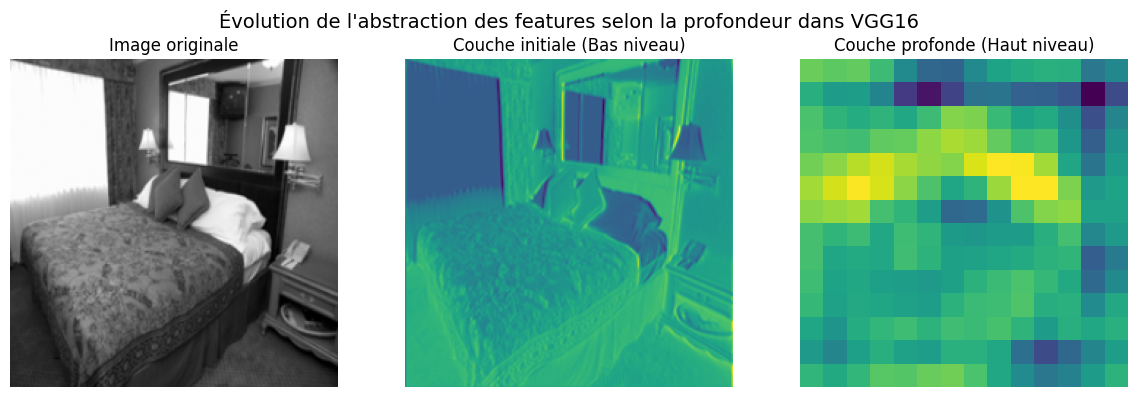

Instanciation de VGG16
Instanciation de VGG16relu7
Data recovery
Feature extraction
Batch 000/188
Batch 050/188
Batch 100/188
Batch 150/188
Batch 000/374
Batch 050/374
Batch 100/374
Batch 150/374
Batch 200/374
Batch 250/374
Batch 300/374
Batch 350/374
Training the SVMs
Accuracy = 0.888107
Génération de la visualisation des prédictions


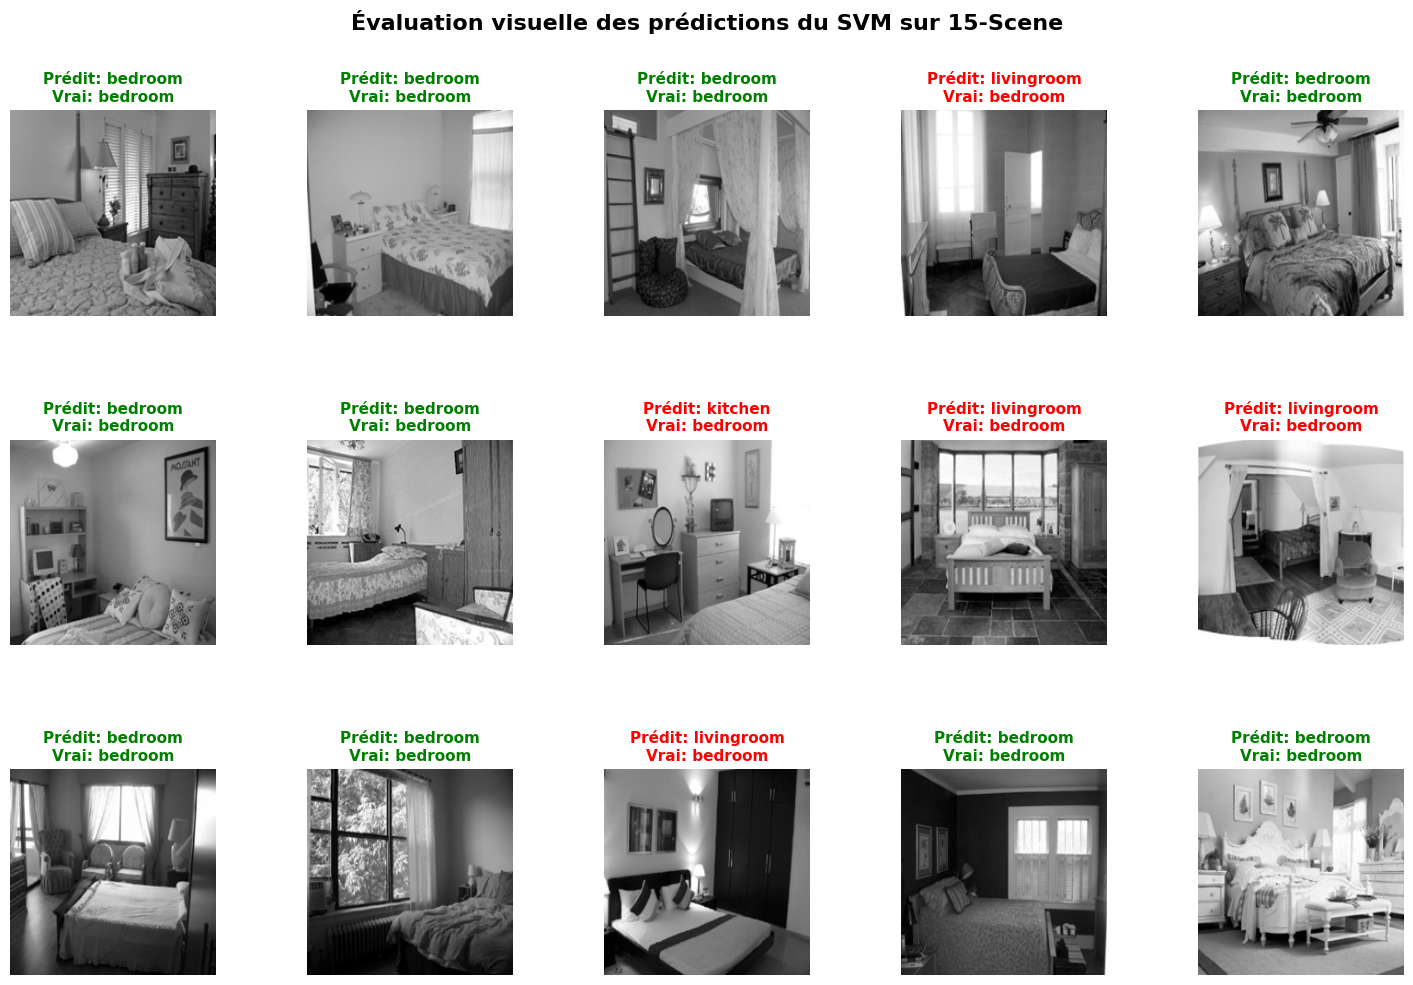

In [8]:
show_activationMaps("../data/15SceneData")
main("../data/15SceneData", 8)